# CoW 3D Post-Processing and 1D Calibration

This notebook analyzes the existing steady-state CFD post-processing exports for `openfoam/segment_test_V2` and compares the slice-derived CFD resistance with reduced-order network data. It does not recreate ParaView slices. OpenFOAM `p` is treated as kinematic pressure and converted using `rho = 1060 kg/m^3`. Because the simulation is steady, systolic/diastolic quantities, OSI, waveform matching, and wall-motion compliance are not computed; they require transient and/or FSI simulations.

## Setup

In [1]:
from pathlib import Path
import csv, os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "openfoam" / "segment_test_V2" / "data"
OUTPUT_DIR = PROJECT_ROOT / "output" / "segment_test_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RHO = 1060.0
PA_PER_MMHG = 133.322
R_TO_MMHG_S_PER_ML = 1.0 / (PA_PER_MMHG * 1e6)
SLICES = ["inlet", "midslice", "outlet"]
NORMALS = {
    "inlet": np.array([0.5103037804570406, -0.8596550644734353, -0.024149985019174598]),
    "midslice": np.array([0.6324414356546973, -0.7702129056188429, 0.08240091313331853]),
    "outlet": np.array([0.4278871251313104, -0.9017025116588478, 0.06200958486385685]),
}
CENTERLINE = PROJECT_ROOT / "data" / "mr_limited" / "geometry" / "segment_test_centerline_candidate.vtu"
RESISTANCE_TABLE = DATA_DIR / "network_resistance_table.csv"

def read_csv_rows(path):
    with path.open(newline="") as handle:
        return list(csv.DictReader(handle))

def write_csv(path, rows):
    keys = []
    for row in rows:
        for key in row:
            if key not in keys:
                keys.append(key)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=keys)
        writer.writeheader()
        writer.writerows(rows)

def markdown_table(rows, columns=None, float_format=".6g"):
    if not rows:
        return "(no rows)"
    if columns is None:
        columns = list(rows[0].keys())
    lines = ["| " + " | ".join(columns) + " |", "| " + " | ".join(["---"] * len(columns)) + " |"]
    for row in rows:
        vals = []
        for col in columns:
            value = row.get(col, "")
            vals.append(format(float(value), float_format) if isinstance(value, (float, np.floating)) else str(value))
        lines.append("| " + " | ".join(vals) + " |")
    return "\n".join(lines)

def show_table(rows, columns=None, title=None):
    body = markdown_table(rows, columns=columns)
    display(Markdown((f"**{title}**\n\n" if title else "") + body))

## Section 1 — Data Audit and Validation

In [2]:
required = []
for name in SLICES:
    required.append((f"{name}_integration_variable.csv", DATA_DIR / f"{name}_integration_variable.csv"))
    required.append((f"{name}_integration.csv", DATA_DIR / f"{name}_integration.csv"))
required += [("centerline", CENTERLINE), ("network_resistance_table.csv", RESISTANCE_TABLE)]

audit_rows = [{"input": label, "path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()} for label, path in required]
write_csv(OUTPUT_DIR / "data_audit_files.csv", audit_rows)
show_table(audit_rows, title="Input file audit")

**Input file audit**

| input | path | exists |
| --- | --- | --- |
| inlet_integration_variable.csv | openfoam/segment_test_V2/data/inlet_integration_variable.csv | True |
| inlet_integration.csv | openfoam/segment_test_V2/data/inlet_integration.csv | True |
| midslice_integration_variable.csv | openfoam/segment_test_V2/data/midslice_integration_variable.csv | True |
| midslice_integration.csv | openfoam/segment_test_V2/data/midslice_integration.csv | True |
| outlet_integration_variable.csv | openfoam/segment_test_V2/data/outlet_integration_variable.csv | True |
| outlet_integration.csv | openfoam/segment_test_V2/data/outlet_integration.csv | True |
| centerline | data/mr_limited/geometry/segment_test_centerline_candidate.vtu | True |
| network_resistance_table.csv | openfoam/segment_test_V2/data/network_resistance_table.csv | True |

In [3]:
integrated, integrated_rows = {}, []
for name in SLICES:
    row = read_csv_rows(DATA_DIR / f"{name}_integration_variable.csv")[0]
    u_int = np.array([float(row["U:0"]), float(row["U:1"]), float(row["U:2"])])
    area = float(row["Area"])
    p_integral = float(row["p"])
    p_avg_kin = p_integral / area
    p_avg_pa = RHO * p_avg_kin
    q = float(np.dot(u_int, NORMALS[name]))
    rec = {"slice": name, "Ux_integral_m3_s": u_int[0], "Uy_integral_m3_s": u_int[1], "Uz_integral_m3_s": u_int[2], "Area_m2": area, "p_integral_kinematic": p_integral, "p_avg_kinematic_m2_s2": p_avg_kin, "p_avg_Pa": p_avg_pa, "p_avg_mmHg": p_avg_pa / PA_PER_MMHG, "Q_m3_s": q, "Q_mL_s": q * 1e6}
    integrated[name] = rec
    integrated_rows.append(rec)
write_csv(OUTPUT_DIR / "slice_integrated_quantities.csv", integrated_rows)
show_table(integrated_rows, title="Integrated slice quantities")
pressure_decreases = integrated["inlet"]["p_avg_Pa"] > integrated["midslice"]["p_avg_Pa"] > integrated["outlet"]["p_avg_Pa"]
display(Markdown(f"**Pressure validation:** {'decreases inlet to midslice to outlet' if pressure_decreases else 'does not strictly decrease'}."))

**Integrated slice quantities**

| slice | Ux_integral_m3_s | Uy_integral_m3_s | Uz_integral_m3_s | Area_m2 | p_integral_kinematic | p_avg_kinematic_m2_s2 | p_avg_Pa | p_avg_mmHg | Q_m3_s | Q_mL_s |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| inlet | 4.74127e-07 | -9.00395e-07 | -2.23462e-07 | 4.98646e-06 | 2.09955e-06 | 0.42105 | 446.313 | 3.34763 | 1.02137e-06 | 1.02137 |
| midslice | 6.73297e-07 | -7.87647e-07 | -6.12541e-08 | 3.09511e-06 | 9.40646e-07 | 0.303913 | 322.148 | 2.41632 | 1.02743e-06 | 1.02743 |
| outlet | 5.16878e-07 | -8.83253e-07 | 1.43555e-07 | 5.68343e-06 | 4.82272e-07 | 0.0848557 | 89.947 | 0.67466 | 1.0265e-06 | 1.0265 |

**Pressure validation:** decreases inlet to midslice to outlet.

## Section 2 — Velocity Field Analysis

Velocity magnitude is computed as `sqrt(Ux^2 + Uy^2 + Uz^2)` from the raw slice distributions.

**Velocity magnitude summary**

| slice | n_samples | mean_velocity_m_s | max_velocity_m_s | std_velocity_m_s | Ux_mean_m_s | Uy_mean_m_s | Uz_mean_m_s | pressure_mean_Pa |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| inlet | 1545 | 0.132329 | 0.419982 | 0.0990166 | 0.0591058 | -0.110575 | -0.0325646 | 447.227 |
| midslice | 994 | 0.218808 | 0.611064 | 0.160087 | 0.140623 | -0.163179 | -0.0139854 | 324.681 |
| outlet | 1447 | 0.126859 | 0.77798 | 0.18806 | 0.0510095 | -0.0927458 | 0.0181106 | 89.3794 |

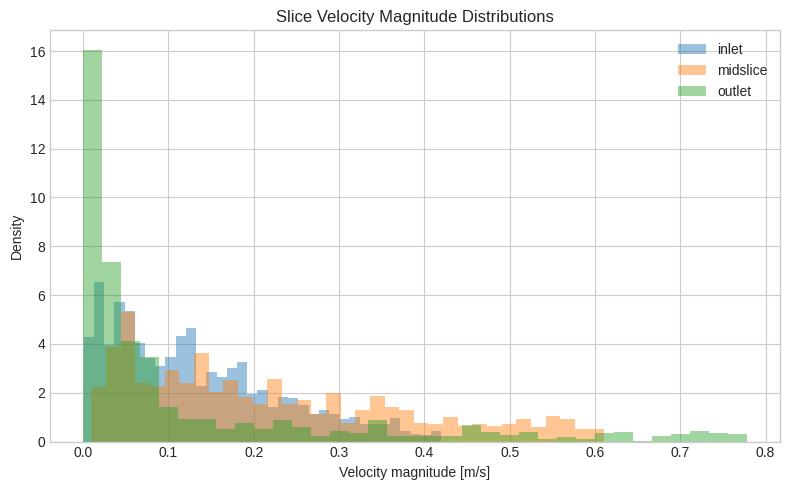

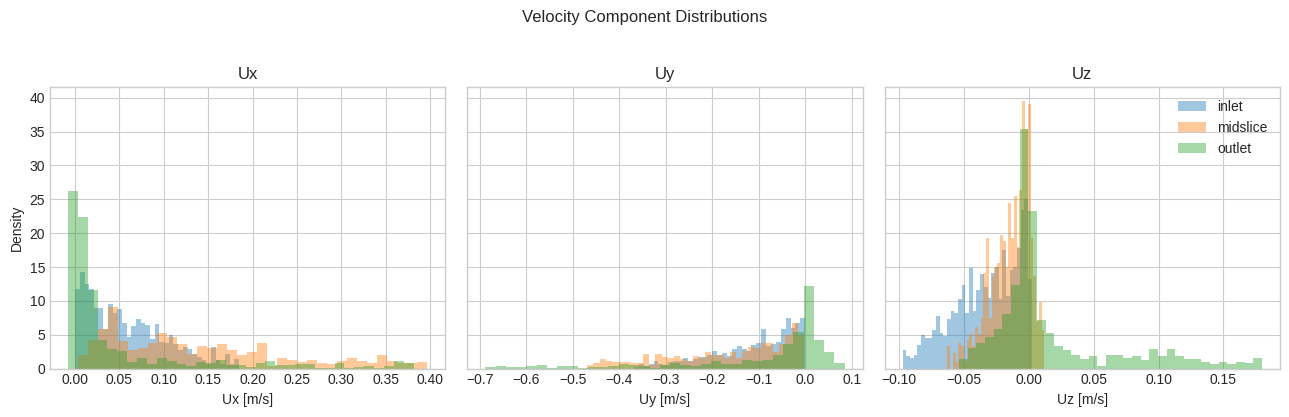

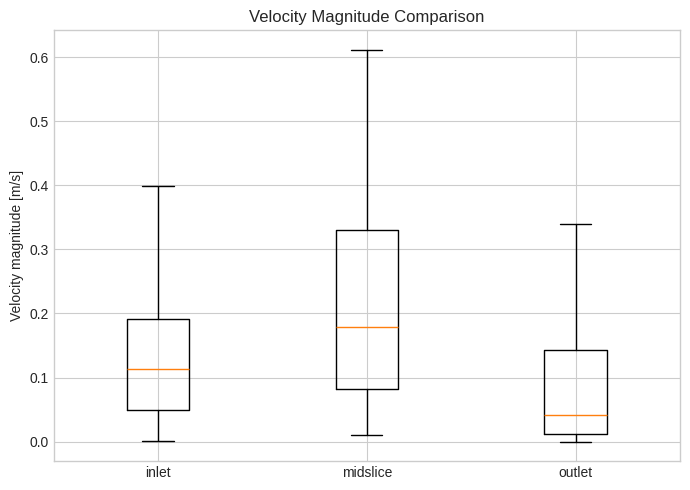

In [4]:
raw, velocity_rows = {}, []
for name in SLICES:
    rows = read_csv_rows(DATA_DIR / f"{name}_integration.csv")
    arr = np.array([[float(r["U:0"]), float(r["U:1"]), float(r["U:2"]), float(r["p"])] for r in rows])
    mag = np.linalg.norm(arr[:, :3], axis=1)
    raw[name] = {"arr": arr, "mag": mag}
    velocity_rows.append({"slice": name, "n_samples": len(rows), "mean_velocity_m_s": float(mag.mean()), "max_velocity_m_s": float(mag.max()), "std_velocity_m_s": float(mag.std(ddof=1)), "Ux_mean_m_s": float(arr[:,0].mean()), "Uy_mean_m_s": float(arr[:,1].mean()), "Uz_mean_m_s": float(arr[:,2].mean()), "pressure_mean_Pa": float(arr[:,3].mean() * RHO)})
write_csv(OUTPUT_DIR / "velocity_slice_summary.csv", velocity_rows)
show_table(velocity_rows, title="Velocity magnitude summary")

plt.style.use("seaborn-v0_8-whitegrid")
colors = {"inlet": "#1f77b4", "midslice": "#ff7f0e", "outlet": "#2ca02c"}
fig, ax = plt.subplots(figsize=(8, 5))
for name in SLICES:
    ax.hist(raw[name]["mag"], bins=35, density=True, alpha=0.45, label=name, color=colors[name])
ax.set(xlabel="Velocity magnitude [m/s]", ylabel="Density", title="Slice Velocity Magnitude Distributions")
ax.legend(); fig.tight_layout(); fig.savefig(OUTPUT_DIR / "velocity_magnitude_histograms.png", dpi=180); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for i, comp in enumerate(["Ux", "Uy", "Uz"]):
    for name in SLICES:
        axes[i].hist(raw[name]["arr"][:, i], bins=35, density=True, alpha=0.42, label=name, color=colors[name])
    axes[i].set_xlabel(f"{comp} [m/s]"); axes[i].set_title(comp)
axes[0].set_ylabel("Density"); axes[-1].legend(); fig.suptitle("Velocity Component Distributions", y=1.03)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "velocity_component_distributions.png", dpi=180, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([raw[name]["mag"] for name in SLICES], tick_labels=SLICES, showfliers=False)
ax.set(ylabel="Velocity magnitude [m/s]", title="Velocity Magnitude Comparison")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "velocity_comparison_boxplot.png", dpi=180); plt.show()

The distributions are visibly non-uniform and component-dependent, which is consistent with curvature effects and deviations from ideal Poiseuille assumptions.

## Section 3 — Flow Rate Extraction

Using integrated velocity exports and known slice normals: `Q = Ux nx + Uy ny + Uz nz`.

In [5]:
q_ref = integrated["inlet"]["Q_m3_s"]
flow_rows = []
for name in SLICES:
    q = integrated[name]["Q_m3_s"]
    err = 100.0 * (q - q_ref) / q_ref
    flow_rows.append({"slice": name, "normal_x": NORMALS[name][0], "normal_y": NORMALS[name][1], "normal_z": NORMALS[name][2], "Q_m3_s": q, "Q_mL_s": q * 1e6, "relative_error_vs_inlet_percent": err, "absolute_relative_error_vs_inlet_percent": abs(err)})
write_csv(OUTPUT_DIR / "flow_rate_summary.csv", flow_rows)
show_table(flow_rows, title="Flow rate from integrated velocity and slice normals")

**Flow rate from integrated velocity and slice normals**

| slice | normal_x | normal_y | normal_z | Q_m3_s | Q_mL_s | relative_error_vs_inlet_percent | absolute_relative_error_vs_inlet_percent |
| --- | --- | --- | --- | --- | --- | --- | --- |
| inlet | 0.510304 | -0.859655 | -0.02415 | 1.02137e-06 | 1.02137 | 0 | 0 |
| midslice | 0.632441 | -0.770213 | 0.0824009 | 1.02743e-06 | 1.02743 | 0.592866 | 0.592866 |
| outlet | 0.427887 | -0.901703 | 0.0620096 | 1.0265e-06 | 1.0265 | 0.501722 | 0.501722 |

## Section 4 — Pressure Analysis

**Pressure drops**

| drop | deltaP_Pa | deltaP_mmHg |
| --- | --- | --- |
| inlet_to_midslice | 124.165 | 0.931315 |
| midslice_to_outlet | 232.201 | 1.74166 |
| inlet_to_outlet | 356.366 | 2.67297 |

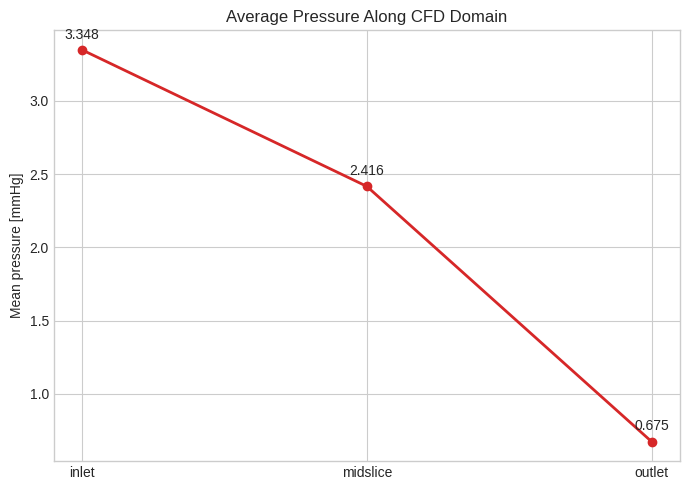

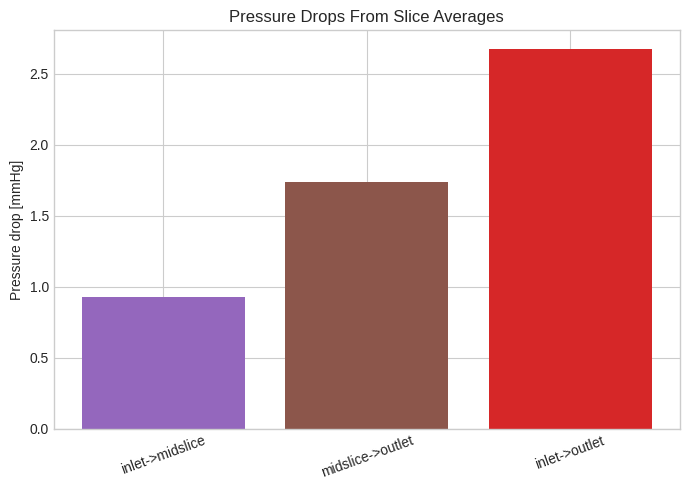

In [6]:
p_in, p_mid, p_out = [integrated[name]["p_avg_Pa"] for name in SLICES]
pressure_rows = [{"drop": "inlet_to_midslice", "deltaP_Pa": p_in - p_mid, "deltaP_mmHg": (p_in - p_mid) / PA_PER_MMHG}, {"drop": "midslice_to_outlet", "deltaP_Pa": p_mid - p_out, "deltaP_mmHg": (p_mid - p_out) / PA_PER_MMHG}, {"drop": "inlet_to_outlet", "deltaP_Pa": p_in - p_out, "deltaP_mmHg": (p_in - p_out) / PA_PER_MMHG}]
write_csv(OUTPUT_DIR / "pressure_drop_summary.csv", pressure_rows)
show_table(pressure_rows, title="Pressure drops")

fig, ax = plt.subplots(figsize=(7, 5))
pressures = [integrated[name]["p_avg_mmHg"] for name in SLICES]
ax.plot(SLICES, pressures, marker="o", linewidth=2, color="#d62728")
for x, y in zip(SLICES, pressures):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
ax.set(ylabel="Mean pressure [mmHg]", title="Average Pressure Along CFD Domain")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "pressure_profile.png", dpi=180); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar([r["drop"].replace("_to_", "->") for r in pressure_rows], [r["deltaP_mmHg"] for r in pressure_rows], color=["#9467bd", "#8c564b", "#d62728"])
ax.set(ylabel="Pressure drop [mmHg]", title="Pressure Drops From Slice Averages")
ax.tick_params(axis="x", rotation=20); fig.tight_layout(); fig.savefig(OUTPUT_DIR / "pressure_drop_segments.png", dpi=180); plt.show()

The pressure drop reflects vessel geometry and tortuosity; the pointwise distribution is richer than a single reduced-order pressure gradient.

## Section 5 — CFD Resistance

In [7]:
dp_total = p_in - p_out
R_CFD = dp_total / q_ref
resistance_rows = [{"quantity": "CFD inlet-outlet resistance", "deltaP_Pa": dp_total, "deltaP_mmHg": dp_total / PA_PER_MMHG, "Q_m3_s": q_ref, "Q_mL_s": q_ref * 1e6, "R_Pa_s_m3": R_CFD, "R_mmHg_s_mL": R_CFD * R_TO_MMHG_S_PER_ML}]
write_csv(OUTPUT_DIR / "cfd_resistance_summary.csv", resistance_rows)
show_table(resistance_rows, title="CFD hydraulic resistance")

**CFD hydraulic resistance**

| quantity | deltaP_Pa | deltaP_mmHg | Q_m3_s | Q_mL_s | R_Pa_s_m3 | R_mmHg_s_mL |
| --- | --- | --- | --- | --- | --- | --- |
| CFD inlet-outlet resistance | 356.366 | 2.67297 | 1.02137e-06 | 1.02137 | 3.48908e+08 | 2.61703 |

## Section 6 — Comparison with Reduced-Order Models

**CFD-domain network rows**

| label | arc_len_mm | r_mean_mm | R0_arith | R0_harm | R_1D | in_CFD_domain |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 18.24 | 2.1647 | 7404032.848323509 | 8068108.895026029 | 7979322.483566353 | ★ |
| 2 | 36.12 | 1.0922 | 226230830.87699783 | 311844094.2725176 | 314746864.2809521 | ★ |
| 8 | 6.61 | 1.4272 | 14196172.345426379 | 15144883.282824699 | 14982303.010907382 | ★ |

**CFD vs reduced-order resistance comparison**

| model | segments_used | R_Pa_s_m3 | R_mmHg_s_mL | percent_error_vs_CFD | absolute_percent_error_vs_CFD |
| --- | --- | --- | --- | --- | --- |
| CFD resistance | inlet-outlet slices | 3.48908e+08 | 2.61703 | 0 | 0 |
| Poiseuille arithmetic radius | 1+2+8 | 2.47831e+08 | 1.85889 | -28.9696 | 28.9696 |
| Poiseuille harmonic radius | 1+2+8 | 3.35057e+08 | 2.51314 | -3.96985 | 3.96985 |
| 1D resistance | 1+2+8 | 3.37708e+08 | 2.53303 | -3.20994 | 3.20994 |

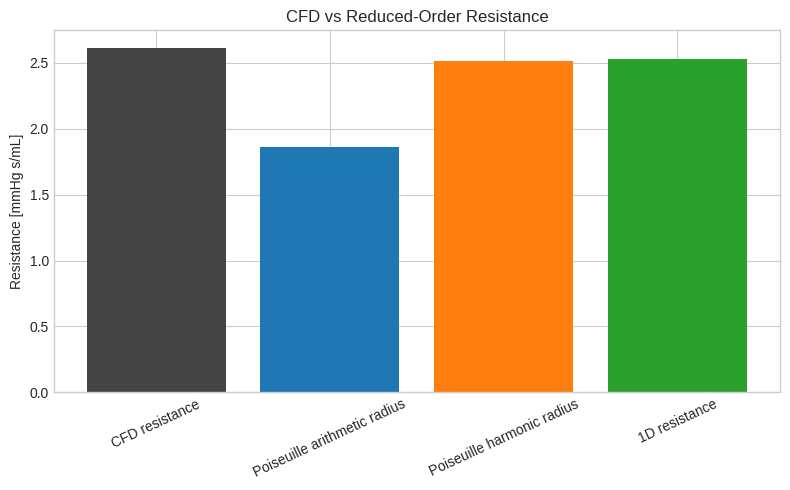

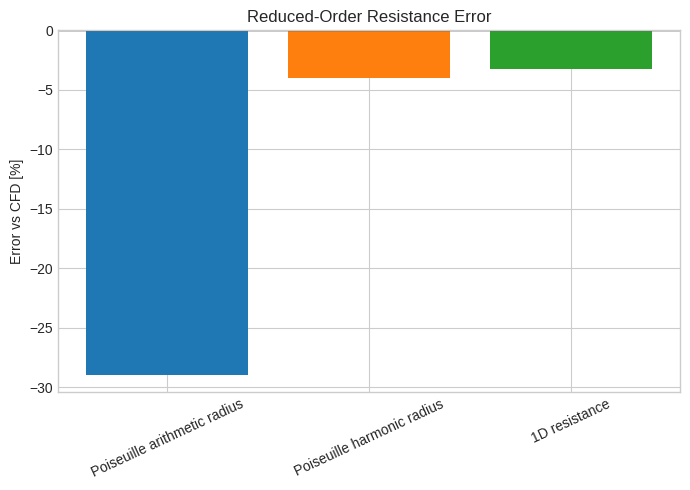

In [8]:
network_rows = read_csv_rows(RESISTANCE_TABLE)
cfd_domain_rows = [row for row in network_rows if row.get("in_CFD_domain", "").strip() == "★"]
show_table(cfd_domain_rows, columns=["label", "arc_len_mm", "r_mean_mm", "R0_arith", "R0_harm", "R_1D", "in_CFD_domain"], title="CFD-domain network rows")
models = {"CFD resistance": R_CFD, "Poiseuille arithmetic radius": sum(float(r["R0_arith"]) for r in cfd_domain_rows), "Poiseuille harmonic radius": sum(float(r["R0_harm"]) for r in cfd_domain_rows), "1D resistance": sum(float(r["R_1D"]) for r in cfd_domain_rows)}
comparison_rows = []
for model, value in models.items():
    err = 100.0 * (value - R_CFD) / R_CFD
    comparison_rows.append({"model": model, "segments_used": "inlet-outlet slices" if model == "CFD resistance" else "+".join(row["label"] for row in cfd_domain_rows), "R_Pa_s_m3": value, "R_mmHg_s_mL": value * R_TO_MMHG_S_PER_ML, "percent_error_vs_CFD": 0.0 if model == "CFD resistance" else err, "absolute_percent_error_vs_CFD": 0.0 if model == "CFD resistance" else abs(err)})
write_csv(OUTPUT_DIR / "reduced_order_comparison.csv", comparison_rows)
show_table(comparison_rows, title="CFD vs reduced-order resistance comparison")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([r["model"] for r in comparison_rows], [r["R_mmHg_s_mL"] for r in comparison_rows], color=["#444444", "#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set(ylabel="Resistance [mmHg s/mL]", title="CFD vs Reduced-Order Resistance")
ax.tick_params(axis="x", rotation=25); fig.tight_layout(); fig.savefig(OUTPUT_DIR / "resistance_comparison_bar.png", dpi=180); plt.show()

err_rows = [r for r in comparison_rows if r["model"] != "CFD resistance"]
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar([r["model"] for r in err_rows], [r["percent_error_vs_CFD"] for r in err_rows], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.axhline(0, color="black", linewidth=1)
ax.set(ylabel="Error vs CFD [%]", title="Reduced-Order Resistance Error")
ax.tick_params(axis="x", rotation=25); fig.tight_layout(); fig.savefig(OUTPUT_DIR / "resistance_error_bar.png", dpi=180); plt.show()

Differences between CFD and reduced-order models can come from radius averaging, discretization, boundary-condition conventions, and curvature/secondary-flow effects that lower-dimensional models collapse into integrated pressure-flow behavior.

## Section 7 — Information Loss During Simplification

In [9]:
info_loss_rows = [
    {"representation": "3D CFD", "preserves": "velocity profile; pressure field; spatial flow structure; curvature effects", "information_lost_or_simplified": "No transient or wall-motion quantities in this steady rigid-wall run"},
    {"representation": "1D model", "preserves": "length; radius; pressure drop; flow rate; network connectivity", "information_lost_or_simplified": "cross-sectional velocity profile; secondary flow; WSS distribution; local pressure patterns; recirculation structures"},
    {"representation": "0D model", "preserves": "global resistance; global flow; global pressure", "information_lost_or_simplified": "spatial pressure field; velocity distribution; curvature-induced structure; local hemodynamic extrema"},
]
write_csv(OUTPUT_DIR / "information_loss_summary.csv", info_loss_rows)
show_table(info_loss_rows, title="Information retained and lost during simplification")
display(Markdown("The raw slice data preserve non-uniform velocity distributions and component asymmetries that are collapsed in 1D and 0D models. Good agreement in resistance therefore means agreement in integrated pressure-flow response, not recovery of the local 3D flow structure."))

**Information retained and lost during simplification**

| representation | preserves | information_lost_or_simplified |
| --- | --- | --- |
| 3D CFD | velocity profile; pressure field; spatial flow structure; curvature effects | No transient or wall-motion quantities in this steady rigid-wall run |
| 1D model | length; radius; pressure drop; flow rate; network connectivity | cross-sectional velocity profile; secondary flow; WSS distribution; local pressure patterns; recirculation structures |
| 0D model | global resistance; global flow; global pressure | spatial pressure field; velocity distribution; curvature-induced structure; local hemodynamic extrema |

The raw slice data preserve non-uniform velocity distributions and component asymmetries that are collapsed in 1D and 0D models. Good agreement in resistance therefore means agreement in integrated pressure-flow response, not recovery of the local 3D flow structure.

## Section 8 — Future Calibration Toward First-Blood

In [10]:
calibration_rows = [
    {"parameter": "resistance", "recommendation": "Fit total 0D/1D resistance to R_CFD after validating pressure drop and flow conservation."},
    {"parameter": "vessel radius", "recommendation": "Prioritize radius profile checks because Poiseuille resistance scales with r^-4."},
    {"parameter": "vessel length", "recommendation": "Use centerline arc length for 1D/0D segment lengths."},
    {"parameter": "discretization density", "recommendation": "Refine where radius or curvature varies rapidly; do not tune it to mimic absent transient effects."},
    {"parameter": "outlet boundary resistance", "recommendation": "Adjust outlet resistance only after internal segment resistance matches CFD pressure drop."},
]
write_csv(OUTPUT_DIR / "future_calibration_recommendations.csv", calibration_rows)
show_table(calibration_rows, title="Calibration framework toward First-Blood")
display(Markdown("No optimization is implemented here. Systolic/diastolic quantities, OSI, waveform matching, and compliance from wall motion require transient or FSI simulations and are intentionally excluded."))

**Calibration framework toward First-Blood**

| parameter | recommendation |
| --- | --- |
| resistance | Fit total 0D/1D resistance to R_CFD after validating pressure drop and flow conservation. |
| vessel radius | Prioritize radius profile checks because Poiseuille resistance scales with r^-4. |
| vessel length | Use centerline arc length for 1D/0D segment lengths. |
| discretization density | Refine where radius or curvature varies rapidly; do not tune it to mimic absent transient effects. |
| outlet boundary resistance | Adjust outlet resistance only after internal segment resistance matches CFD pressure drop. |

No optimization is implemented here. Systolic/diastolic quantities, OSI, waveform matching, and compliance from wall motion require transient or FSI simulations and are intentionally excluded.

## Saved Outputs

In [11]:
scalar_rows = [{"quantity": "pressure_decreases_inlet_to_outlet", "value": pressure_decreases, "unit": "-"}, {"quantity": "Q_inlet", "value": q_ref, "unit": "m3/s"}, {"quantity": "Q_inlet", "value": q_ref * 1e6, "unit": "mL/s"}, {"quantity": "deltaP_inlet_outlet", "value": dp_total, "unit": "Pa"}, {"quantity": "R_CFD", "value": R_CFD, "unit": "Pa s/m3"}, {"quantity": "R_CFD", "value": R_CFD * R_TO_MMHG_S_PER_ML, "unit": "mmHg s/mL"}]
write_csv(OUTPUT_DIR / "analysis_scalar_summary.csv", scalar_rows)
show_table(scalar_rows, title="Key scalar outputs")
saved = sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
display(Markdown("**Saved derived outputs in `output/segment_test_v2/`:**\n\n" + "\n".join(f"- `{name}`" for name in saved)))

**Key scalar outputs**

| quantity | value | unit |
| --- | --- | --- |
| pressure_decreases_inlet_to_outlet | True | - |
| Q_inlet | 1.02137e-06 | m3/s |
| Q_inlet | 1.02137 | mL/s |
| deltaP_inlet_outlet | 356.366 | Pa |
| R_CFD | 3.48908e+08 | Pa s/m3 |
| R_CFD | 2.61703 | mmHg s/mL |

**Saved derived outputs in `output/segment_test_v2/`:**

- `analysis_scalar_summary.csv`
- `cfd_resistance_summary.csv`
- `data_audit_files.csv`
- `flow_rate_summary.csv`
- `future_calibration_recommendations.csv`
- `information_loss_summary.csv`
- `pressure_drop_segments.png`
- `pressure_drop_summary.csv`
- `pressure_profile.png`
- `reduced_order_comparison.csv`
- `resistance_comparison_bar.png`
- `resistance_error_bar.png`
- `slice_integrated_quantities.csv`
- `velocity_comparison_boxplot.png`
- `velocity_component_distributions.png`
- `velocity_magnitude_histograms.png`
- `velocity_slice_summary.csv`